# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Mahesa Masracesara
- Email:mahesa.masracesara@gmail.com
- Id Dicoding: mahesahesa12

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv("data.csv", sep=";")

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
# Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Dataset memiliki 4424 baris data mahasiswa dan 37 fitur yang mencakup informasi demografi, akademik, serta kondisi ekonomi mahasiswa.

In [4]:
# Statistik Deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [5]:
# Cek missing values
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


## Data Preparation / Preprocessing

In [6]:
# Encoding Target
df["Status"] = df["Status"].apply(lambda x: 1 if x == "Dropout" else 0)

Variabel Status pada dataset memiliki tiga kategori yaitu Dropout, Graduate, dan Enrolled. Karena tujuan utama proyek ini adalah mendeteksi mahasiswa yang berpotensi mengalami dropout, maka variabel target diubah menjadi bentuk biner, yaitu:

1 untuk mahasiswa dengan status Dropout

0 untuk mahasiswa dengan status selain Dropout



In [7]:
# Encoding Variabel Kategorikal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

Beberapa fitur dalam dataset berupa data kategorikal yang tidak dapat langsung diproses oleh algoritma machine learning. Oleh karena itu dilakukan proses encoding untuk mengubah nilai kategorikal menjadi representasi numerik sehingga dapat digunakan dalam proses pemodelan.



In [8]:
# memilih fitur yang akan digunakan di aplikasi
features = [
    "Age_at_enrollment",
    "Admission_grade",
    "Scholarship_holder",
    "Tuition_fees_up_to_date"
]

X = df[features]
y = df["Status"]

X.head()

,Age_at_enrollment,Admission_grade,Scholarship_holder,Tuition_fees_up_to_date
0,20,127.3,0,1
1,19,142.5,0,0
2,19,124.8,0,0
3,20,119.6,0,1
4,45,141.5,0,1


In [9]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Dataset kemudian dibagi menjadi data latih (training set) dan data uji (testing set) dengan perbandingan 80:20. Data latih digunakan untuk melatih model machine learning, sedangkan data uji digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya.



In [11]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Proses feature scaling dilakukan untuk menormalkan nilai fitur numerik agar berada dalam skala yang sama. Hal ini penting terutama bagi beberapa algoritma machine learning yang sensitif terhadap perbedaan skala fitur.

## Exploratory Data Analysis (EDA)

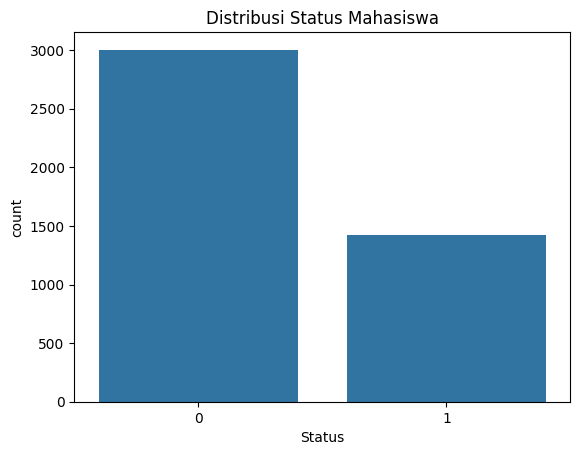

In [12]:
# Distribusi Status Mahasiswa
sns.countplot(x="Status", data=df)
plt.title("Distribusi Status Mahasiswa")
plt.show()


Visualisasi ini menunjukkan distribusi status mahasiswa dalam dataset, yang telah dikategorikan menjadi dua kelas yaitu mahasiswa yang mengalami dropout (1) dan mahasiswa yang tidak dropout (0).


Berdasarkan grafik tersebut terlihat bahwa jumlah mahasiswa yang tidak mengalami dropout lebih banyak dibandingkan mahasiswa yang dropout. Hal ini menunjukkan bahwa dataset memiliki distribusi kelas yang relatif tidak seimbang, di mana sebagian besar mahasiswa berhasil melanjutkan atau menyelesaikan studinya.

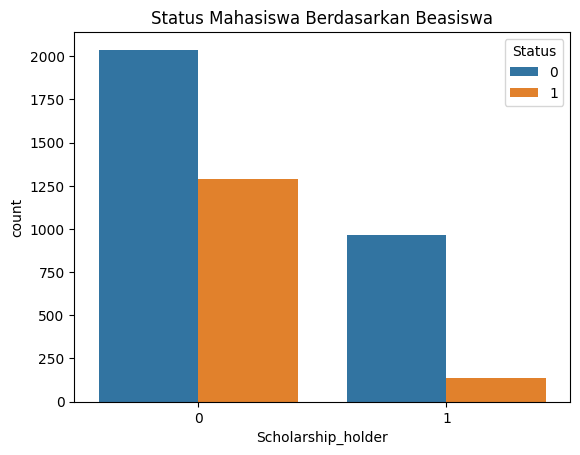

In [13]:
# Pengaruh Beasiswa terhadap Dropout
sns.countplot(x="Scholarship_holder", hue="Status", data=df)
plt.title("Status Mahasiswa Berdasarkan Beasiswa")
plt.show()


Visualisasi ini menunjukkan hubungan antara status penerimaan beasiswa (Scholarship_holder) dengan status mahasiswa (dropout atau tidak).


Terlihat bahwa mahasiswa yang tidak menerima beasiswa lebih banyak mengalami dropout dibandingkan mahasiswa yang menerima beasiswa. Hal ini menunjukkan bahwa dukungan finansial seperti beasiswa dapat berperan dalam membantu mahasiswa menyelesaikan studinya.

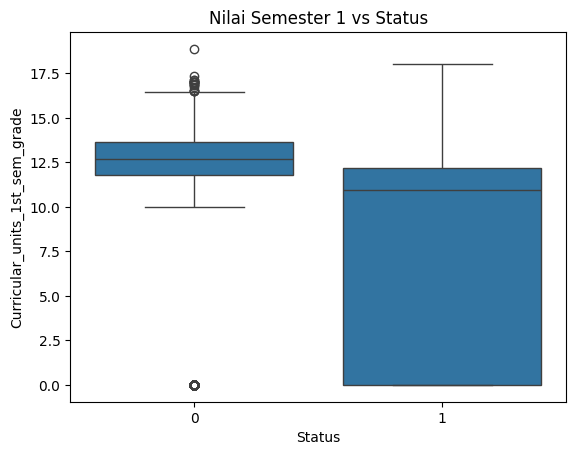

In [14]:
# Pengaruh Nilai Akademik
sns.boxplot(x="Status", y="Curricular_units_1st_sem_grade", data=df)
plt.title("Nilai Semester 1 vs Status")
plt.show()

Boxplot ini menunjukkan distribusi nilai akademik mahasiswa pada semester pertama berdasarkan status mahasiswa.


Mahasiswa yang tidak mengalami dropout cenderung memiliki nilai semester pertama yang lebih tinggi, sedangkan mahasiswa yang mengalami dropout memiliki distribusi nilai yang lebih rendah. Hal ini menunjukkan bahwa performa akademik merupakan salah satu faktor penting yang mempengaruhi kemungkinan mahasiswa mengalami dropout.

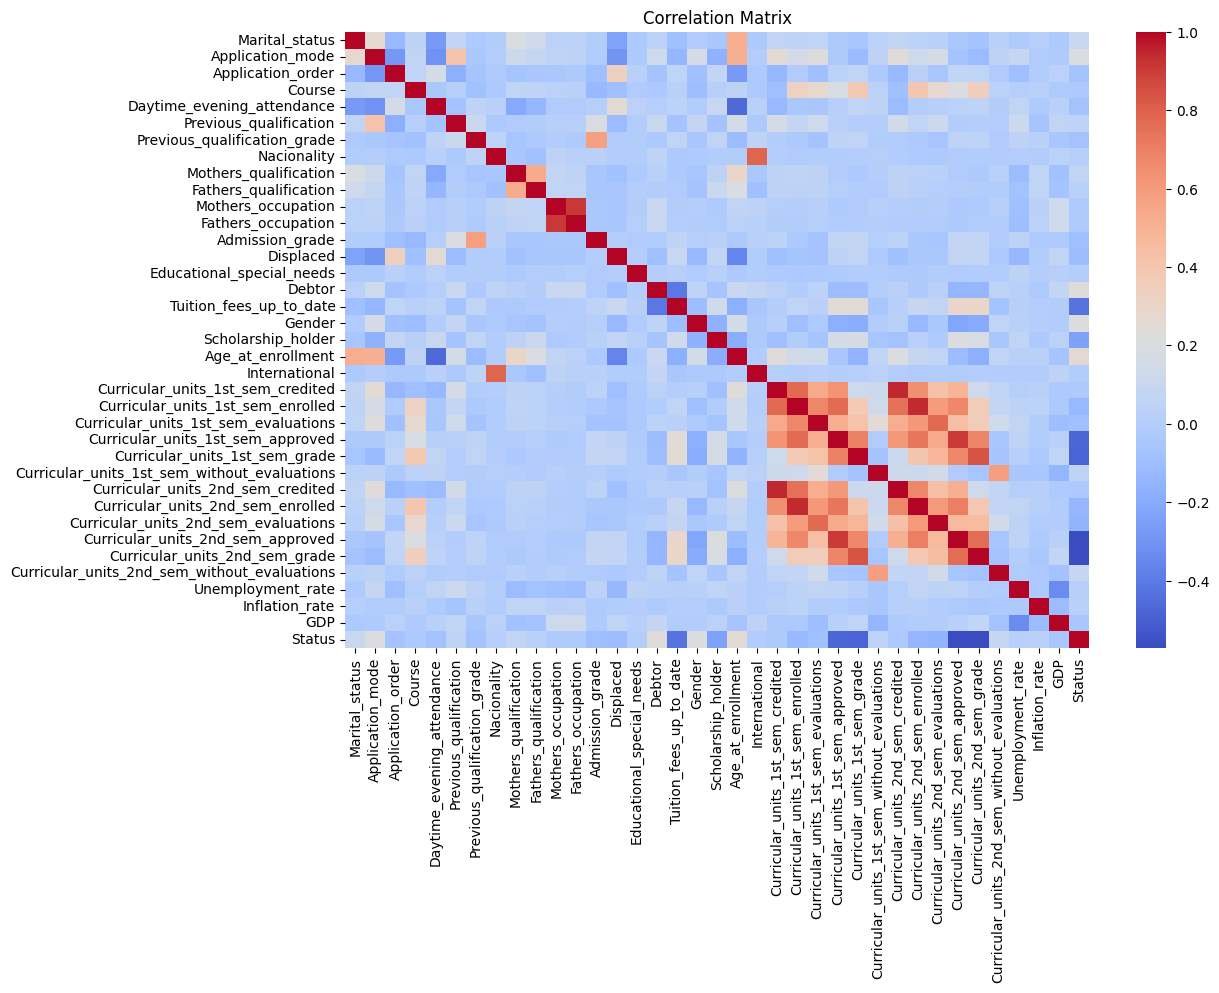

In [15]:
# Korelasi Fitur
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Heatmap ini menunjukkan korelasi antar fitur dalam dataset, yang membantu memahami hubungan antar variabel serta melihat fitur mana yang memiliki hubungan kuat dengan fitur lainnya.


Terlihat bahwa beberapa fitur yang berkaitan dengan performansi akademik, seperti jumlah unit mata kuliah yang disetujui dan nilai semester, memiliki korelasi yang cukup kuat satu sama lain. Hal ini menunjukkan bahwa faktor akademik memiliki hubungan yang signifikan dalam menentukan keberhasilan mahasiswa dalam menyelesaikan studinya.

## Modeling

In [16]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [17]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Evaluation

In [18]:
# Logistic Regression
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7423728813559322
              precision    recall  f1-score   support

           0       0.73      0.95      0.83       569
           1       0.80      0.37      0.51       316

    accuracy                           0.74       885
   macro avg       0.77      0.66      0.67       885
weighted avg       0.76      0.74      0.71       885



Berdasarkan hasil evaluasi, model Logistic Regression menghasilkan nilai akurasi sebesar:

- Accuracy = 0.74 (74%)

Hal ini menunjukkan bahwa model mampu memprediksi status mahasiswa dengan tingkat ketepatan sekitar 74%.

Interpretasi Classification Report
Untuk kelas 0 (tidak dropout):

- Precision: 0.73

- Recall: 0.95

- F1-score: 0.83

Artinya model sangat baik dalam mengenali mahasiswa yang tidak mengalami dropout.

Untuk kelas 1 (dropout):

- Precision: 0.80

- Recall: 0.37

- F1-score: 0.51

Nilai recall yang cukup rendah menunjukkan bahwa model masih kesulitan mendeteksi sebagian mahasiswa yang benar-benar mengalami dropout.

In [19]:
# Random Forest
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6802259887005649
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       569
           1       0.56      0.46      0.51       316

    accuracy                           0.68       885
   macro avg       0.65      0.63      0.64       885
weighted avg       0.67      0.68      0.67       885



Model Random Forest menghasilkan nilai akurasi sebesar:

- Accuracy = 0.68 (68%)

Nilai ini lebih rendah dibandingkan model Logistic Regression.

Interpretasi Classification Report
Untuk kelas 0 (tidak dropout):

- Precision: 0.73

- Recall: 0.81

- F1-score: 0.77

Untuk kelas 1 (dropout):

- Precision: 0.56

- Recall: 0.46

- F1-score: 0.51

Hal ini menunjukkan bahwa model Random Forest masih memiliki keterbatasan dalam mengidentifikasi mahasiswa yang benar-benar mengalami dropout.

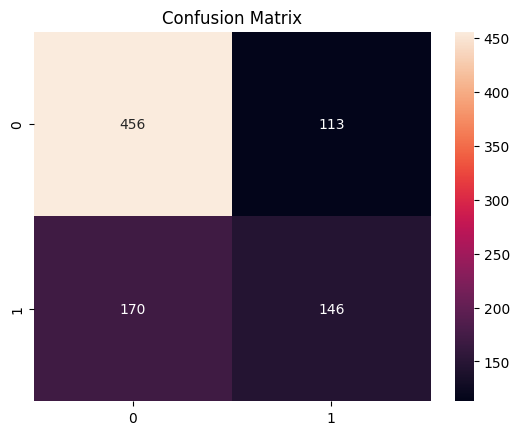

In [20]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

Interpretasi

- 456 mahasiswa berhasil diprediksi dengan benar sebagai tidak dropout.

- 146 mahasiswa berhasil diprediksi dengan benar sebagai dropout.

- 113 mahasiswa diprediksi dropout padahal sebenarnya tidak.

- 170 mahasiswa yang sebenarnya dropout tidak berhasil terdeteksi oleh model.

Nilai False Negative yang cukup tinggi menunjukkan bahwa model masih melewatkan beberapa mahasiswa yang berpotensi dropout.

Berdasarkan hasil evaluasi, model Logistic Regression menunjukkan performa yang lebih baik dibandingkan Random Forest, dengan akurasi sebesar 74%.

Oleh karena itu, model Logistic Regression dipilih sebagai model yang digunakan dalam sistem prediksi dropout mahasiswa pada prototype aplikasi.

Model ini dapat digunakan sebagai early warning system untuk membantu institusi pendidikan dalam mengidentifikasi mahasiswa yang berpotensi mengalami dropout sehingga dapat dilakukan intervensi lebih awal.

In [21]:
# Simpan Model
import pickle

# simpan model Logistic Regression
pickle.dump(lr, open("model.pkl", "wb"))